**Stroke Prediction using Clinical & Lifestyle Features**

***Setup and Unzip***

In [6]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Unzip the file (Make sure you uploaded 'archive.zip' to the sidebar)
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('stroke_project')

# Load the data
df = pd.read_csv('stroke_project/healthcare-dataset-stroke-data.csv')
print("Step 1 Complete: Dataset Loaded!")
df.head()

Step 1 Complete: Dataset Loaded!


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Data Cleaning (Clinical & Lifestyle)**

In [7]:
# 1. Fill missing BMI values with the median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# 2. Remove 'id' column
df_cleaned = df.drop(columns=['id'])

# 3. Handle 'Other' in gender (rare case)
df_cleaned = df_cleaned[df_cleaned['gender'] != 'Other']

# 4. Convert text categories to numbers (Encoding)
df_final = pd.get_dummies(df_cleaned, drop_first=True)

print("Step 2 Complete: Missing values fixed and data encoded!")
df_final.head()

Step 2 Complete: Missing values fixed and data encoded!


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


**Visualizing the Lifestyle Factors**

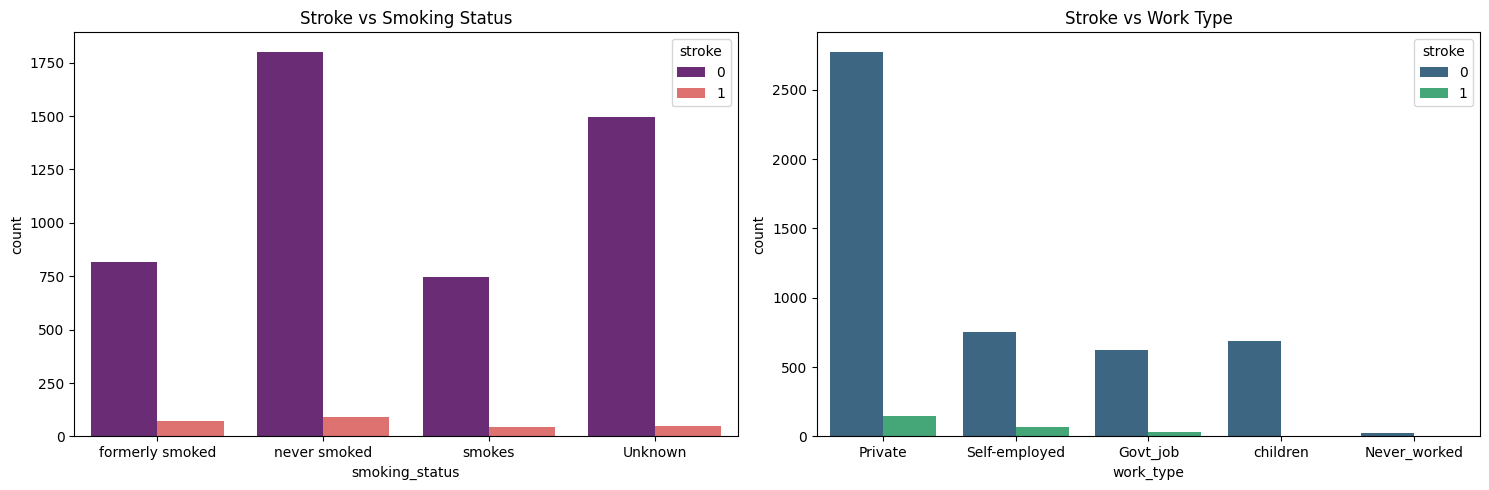

In [8]:
plt.figure(figsize=(15, 5))

# Plot 1: Smoking Status
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='smoking_status', hue='stroke', palette='magma')
plt.title('Stroke vs Smoking Status')

# Plot 2: Work Type
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='work_type', hue='stroke', palette='viridis')
plt.title('Stroke vs Work Type')

plt.tight_layout()
plt.show()

**Splitting and Balancing the Data (SMOTE)**

In [9]:
# Define Features (X) and Target (y)
X = df_final.drop('stroke', axis=1)
y = df_final['stroke']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Step 4 Complete: Training set now has {len(X_train_bal)} balanced samples.")

Step 4 Complete: Training set now has 7800 balanced samples.


**Training and Final Output**

======= FINAL PROJECT RESULTS =======
[[931  29]
 [ 56   6]]

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       960
           1       0.17      0.10      0.12        62

    accuracy                           0.92      1022
   macro avg       0.56      0.53      0.54      1022
weighted avg       0.90      0.92      0.91      1022



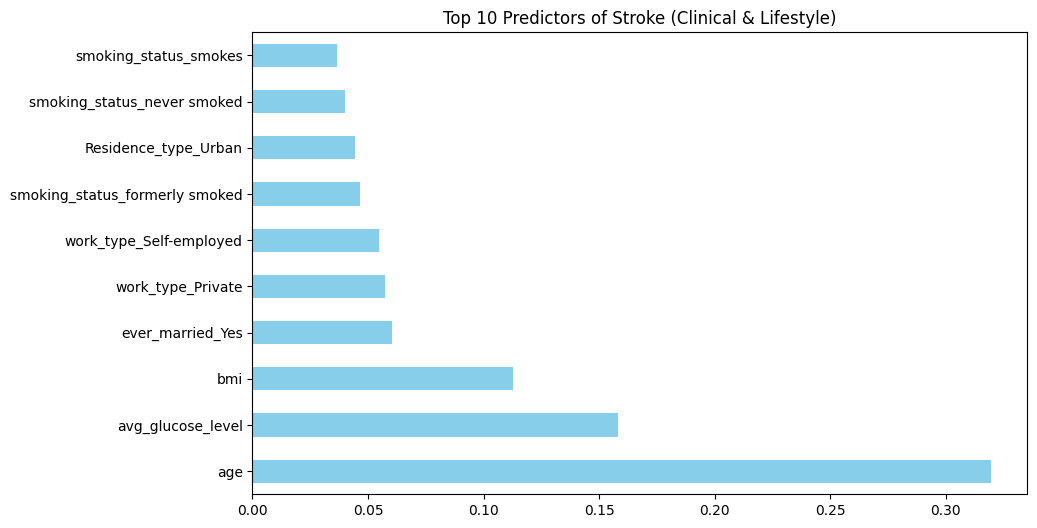

In [10]:
# Initialize and Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_bal, y_train_bal)

# Make Predictions
y_pred = model.predict(X_test)

# FINAL OUTPUT
print("======= FINAL PROJECT RESULTS =======")
print(confusion_matrix(y_test, y_pred))
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

# FEATURE IMPORTANCE (Which lifestyle/clinical factors matter most?)
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Predictors of Stroke (Clinical & Lifestyle)')
plt.show()

**Accuracy of the model**

In [13]:
from sklearn.metrics import accuracy_score

# This calculates and prints ONLY the accuracy percentage
final_acc = accuracy_score(y_test, y_pred)

print("==============================")
print(f"FINAL MODEL ACCURACY: {final_acc * 100:.2f}%")
print("==============================")

FINAL MODEL ACCURACY: 91.68%
